# GO & Pathway Analysis for Novel DEGs
## Genes: LINC02728, LOC100128906, TMIGD3, LUADT1

**Context:** These 4 genes were identified as significant DEGs in a radioresistance study
(integrin αvβ3 / thyroid hormone axis), filtered against CTD, Open Targets, and GeneCards.
Three are non-coding RNAs or a pseudogene, requiring a guilt-by-association strategy.

### Gene Background
| Gene | Type | Known Biology |
|------|------|---------------|
| **TMIGD3** | Protein-coding | Suppresses NF-κB, PKA–Akt axis; tumour suppressor in osteosarcoma |
| **LUADT1** | lncRNA | Binds SUZ12/PRC2; epigenetically suppresses p27; promotes cell cycle progression in lung adenocarcinoma |
| **LOC100128906** | Pseudogene | WDR45-like pseudogene; parent gene involved in autophagy (PI3K complex) |
| **LINC02728** | lncRNA | Poorly characterized; co-expression approach used |

> **Strategy:** Direct GO enrichment for TMIGD3 (protein-coding), guilt-by-association
> using literature-derived interactors for the lncRNAs/pseudogene, and co-expression
> extraction from your own matrix for LINC02728.


## 1. Install & Load Packages

In [1]:
# Run once — comment out after first install
if (!requireNamespace("BiocManager", quietly = TRUE)) install.packages("BiocManager")

BiocManager::install(c(
  "clusterProfiler",
  "org.Hs.eg.db",
  "enrichplot",
  "AnnotationDbi",
  "ReactomePA",
  "DOSE"
), update = FALSE, ask = FALSE)

install.packages(c("ggplot2", "dplyr", "stringr"), repos = "https://cloud.r-project.org")


'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.2 (2025-10-31 ucrt)

Warning message:
"package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'AnnotationDbi'"
Installing package(s) 'clusterProfiler', 'org.Hs.eg.db', 'enrichplot',
  'ReactomePA', 'DOSE'

also installing the dependencies 'fontBitstreamVera', 'fontLiberation', 'fontquiver', 'gridGraphics', 'tweenr', 'polyclip', 'gdtools', 'ggplotify', 'ggforce', 'ape', 'tidytree', 'treeio', 'ggiraph', 'viridis', 'tidygraph', 'graphlayouts', 'graph', 'dir.expiry', 'fastmatch', 'GO.db', 'GOSemSim', 'gson', 'igraph', 'qvalue', 'yulab.utils', 'aplot', 'ggfun', 'ggnewscale', 'ggtangle', 'tidydr', 'scatterpie', 'ggtree', 'ggraph', 'reactome.db', 'graphite', 'fgsea'




package 'fontBitstreamVera' successfully unpacked and MD5 sums checked
package 'fontLiberation' successfully unpacked and MD5 sums checked
package 'fontquiver' successfully unpacked and MD5 sums checked
package 'gridGraphics' successfully unpacked and MD5 sums checked
package 'tweenr' successfully unpacked and MD5 sums checked
package 'polyclip' successfully unpacked and MD5 sums checked
package 'gdtools' successfully unpacked and MD5 sums checked
package 'ggplotify' successfully unpacked and MD5 sums checked
package 'ggforce' successfully unpacked and MD5 sums checked
package 'ape' successfully unpacked and MD5 sums checked
package 'tidytree' successfully unpacked and MD5 sums checked
package 'treeio' successfully unpacked and MD5 sums checked
package 'ggiraph' successfully unpacked and MD5 sums checked
package 'viridis' successfully unpacked and MD5 sums checked
package 'tidygraph' successfully unpacked and MD5 sums checked
package 'graphlayouts' successfully unpacked and MD5 sums ch

installing the source packages 'GO.db', 'reactome.db', 'org.Hs.eg.db'


Installing packages into 'C:/Users/Augustine Nwafor/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'ggplot2' successfully unpacked and MD5 sums checked
package 'dplyr' successfully unpacked and MD5 sums checked
package 'stringr' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Augustine Nwafor\AppData\Local\Temp\RtmpGg4n5x\downloaded_packages


In [2]:
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(AnnotationDbi)
library(ReactomePA)
library(ggplot2)
library(dplyr)

cat("All packages loaded successfully\n")


Warning message:
"package 'clusterProfiler' was built under R version 4.5.3"


clusterProfiler v4.18.4 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

G Yu. Thirteen years of clusterProfiler. The Innovation. 2024,
5(6):100722


Attaching package: 'clusterProfiler'


The following object is masked from 'package:stats':

    filter


Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: 'generics'


The following objects are masked from 'package:base':

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: 'BiocGenerics'


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, eval

All packages loaded successfully


## 2. Direct GO Annotation — TMIGD3 (Protein-Coding)

TMIGD3 is your only protein-coding gene and can be queried directly against GO databases.
Its known mechanism: suppression of the PKA–Akt–NF-κB axis in osteosarcoma.


In [3]:
# Map TMIGD3 symbol to Entrez ID
tmigd3_entrez <- mapIds(
  org.Hs.eg.db,
  keys      = "TMIGD3",
  column    = "ENTREZID",
  keytype   = "SYMBOL",
  multiVals = "first"
)
cat("TMIGD3 Entrez ID:", tmigd3_entrez, "\n")


'select()' returned 1:1 mapping between keys and columns



TMIGD3 Entrez ID: 57413 


In [4]:
# GO enrichment — Biological Process
tmigd3_go_bp <- enrichGO(
  gene          = tmigd3_entrez,
  OrgDb         = org.Hs.eg.db,
  ont           = "BP",
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  readable      = TRUE
)

# GO enrichment — Molecular Function
tmigd3_go_mf <- enrichGO(
  gene          = tmigd3_entrez,
  OrgDb         = org.Hs.eg.db,
  ont           = "MF",
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  readable      = TRUE
)

# GO enrichment — Cellular Component
tmigd3_go_cc <- enrichGO(
  gene          = tmigd3_entrez,
  OrgDb         = org.Hs.eg.db,
  ont           = "CC",
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  readable      = TRUE
)

cat("TMIGD3 GO-BP terms found:", nrow(as.data.frame(tmigd3_go_bp)), "\n")
cat("TMIGD3 GO-MF terms found:", nrow(as.data.frame(tmigd3_go_mf)), "\n")
cat("TMIGD3 GO-CC terms found:", nrow(as.data.frame(tmigd3_go_cc)), "\n")
head(as.data.frame(tmigd3_go_bp)[, c("Description", "pvalue", "p.adjust", "geneID")])


No gene sets have size between 10 and 500 ...

--> return NULL...

No gene sets have size between 10 and 500 ...

--> return NULL...



TMIGD3 GO-BP terms found: 17 
TMIGD3 GO-MF terms found: 0 
TMIGD3 GO-CC terms found: 0 


,Description,pvalue,p.adjust,geneID
,<chr>,<dbl>,<dbl>,<chr>
GO:0007190,activation of adenylate cyclase activity,0.000795334,0.005408271,TMIGD3
GO:0045762,positive regulation of adenylate cyclase activity,0.001060445,0.005408271,TMIGD3
GO:0051349,positive regulation of lyase activity,0.001219512,0.005408271,TMIGD3
GO:0031281,positive regulation of cyclase activity,0.001325557,0.005408271,TMIGD3
GO:0045761,regulation of adenylate cyclase activity,0.001590668,0.005408271,TMIGD3
GO:0032088,negative regulation of NF-kappaB transcription factor activity,0.002386002,0.006760339,TMIGD3


In [5]:
# Reactome pathway for TMIGD3
tmigd3_reactome <- enrichPathway(
  gene         = tmigd3_entrez,
  pvalueCutoff = 0.05,
  readable     = TRUE
)
cat("TMIGD3 Reactome pathways found:", nrow(as.data.frame(tmigd3_reactome)), "\n")
head(as.data.frame(tmigd3_reactome)[, c("Description", "pvalue", "p.adjust", "geneID")])


--> No gene can be mapped....

--> Expected input gene ID: 89890,23396,6137,2224,3811,10533

--> return NULL...



TMIGD3 Reactome pathways found: 0 


ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'head': undefined columns selected


## 3. Guilt-by-Association — Surrogate Gene Sets

Since LUADT1, LOC100128906, and LINC02728 are non-coding or a pseudogene, they have
minimal direct GO annotation. The accepted approach is to use known interacting or
functionally related protein-coding genes derived from literature.

**Literature-derived surrogates:**
- **LUADT1** → binds SUZ12 (PRC2 complex core); epigenetically suppresses CDKN1B (p27)
- **LOC100128906** → WDR45-like; parent gene WDR45 functions in autophagy via PI3K complex
- **TMIGD3** → PKA–Akt–NF-κB axis genes; adenosine A3 receptor (ADORA3) shares N-terminal region
- **LINC02728** → co-expression approach (see Section 4 below)


In [6]:
# Define surrogate gene sets from published literature
surrogate_genes <- c(
  # LUADT1: PRC2 complex components + target gene
  "SUZ12", "EZH2", "EED", "CDKN1B",

  # LOC100128906: WDR45 parent gene + autophagy complex partners
  "WDR45", "PIK3C3", "BECN1", "ATG14", "WIPI4",

  # TMIGD3: PKA-Akt-NF-kB pathway + related receptor
  "PRKACA", "AKT1", "RELA", "NFKB1", "ADORA3"
  # NOTE: LINC02728 co-expressed genes will be added in Section 4
)

# Map to Entrez IDs
surrogate_entrez <- bitr(
  surrogate_genes,
  fromType  = "SYMBOL",
  toType    = "ENTREZID",
  OrgDb     = org.Hs.eg.db
)

cat("Successfully mapped", nrow(surrogate_entrez), "of", length(surrogate_genes), "surrogate genes\n")
print(surrogate_entrez)


'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(surrogate_genes, fromType = "SYMBOL", toType = "ENTREZID", :
"7.14% of input gene IDs are fail to map..."


Successfully mapped 13 of 14 surrogate genes
   SYMBOL ENTREZID
1   SUZ12    23512
2    EZH2     2146
3     EED     8726
4  CDKN1B     1027
5   WDR45    11152
6  PIK3C3     5289
7   BECN1     8678
8   ATG14    22863
10 PRKACA     5566
11   AKT1      207
12   RELA     5970
13  NFKB1     4790
14 ADORA3      140


## 4. Co-expression Analysis for LINC02728

LINC02728 has no published functional characterization. The best approach is to extract
its top co-expressed protein-coding genes from your own normalized expression matrix
(VST, rlog, or TMM counts). These co-expressed partners are then added to the surrogate set.

**Replace `expr_matrix` with your actual matrix object.**


In [7]:
# ============================================================
# ACTION REQUIRED: Replace 'expr_matrix' with your actual
# normalized expression matrix (genes as rows, samples as cols)
# e.g., vst_matrix, rlog_matrix, tmm_counts, etc.
# ============================================================

# --- Template code — uncomment and adapt ---

# Step 1: Extract LINC02728 expression vector
# linc02728_expr <- expr_matrix["LINC02728", ]

# Step 2: Compute Spearman correlation with all other genes
# cors <- apply(expr_matrix, 1, function(g) {
#   cor(as.numeric(linc02728_expr), as.numeric(g),
#       method = "spearman", use = "complete.obs")
# })

# Step 3: Remove LINC02728 itself and non-protein-coding genes
# cors <- cors[names(cors) != "LINC02728"]

# Step 4: Take top 50 positively correlated genes
# top_coexpressed <- names(sort(cors, decreasing = TRUE))[1:50]
# cat("Top co-expressed genes with LINC02728:\n")
# print(top_coexpressed)

# Step 5: Map to Entrez and merge with surrogate set
# linc_entrez <- bitr(top_coexpressed, fromType="SYMBOL",
#                     toType="ENTREZID", OrgDb=org.Hs.eg.db)
# surrogate_entrez <- rbind(surrogate_entrez, linc_entrez)
# surrogate_entrez <- distinct(surrogate_entrez)  # remove duplicates
# cat("Total surrogate genes after adding LINC02728 co-expressed partners:",
#     nrow(surrogate_entrez), "\n")

cat("NOTE: Run the co-expression block above with your expression matrix\n")
cat("to add LINC02728 partners before proceeding.\n")


NOTE: Run the co-expression block above with your expression matrix
to add LINC02728 partners before proceeding.


## 5. GO Enrichment on Full Surrogate Gene Set

This enrichment captures the collective biological context of all four genes
through their known and co-expressed partners.


In [8]:
# GO — Biological Process
go_bp <- enrichGO(
  gene          = surrogate_entrez$ENTREZID,
  OrgDb         = org.Hs.eg.db,
  ont           = "BP",
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  readable      = TRUE
)

# GO — Molecular Function
go_mf <- enrichGO(
  gene          = surrogate_entrez$ENTREZID,
  OrgDb         = org.Hs.eg.db,
  ont           = "MF",
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  readable      = TRUE
)

# GO — Cellular Component
go_cc <- enrichGO(
  gene          = surrogate_entrez$ENTREZID,
  OrgDb         = org.Hs.eg.db,
  ont           = "CC",
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  readable      = TRUE
)

cat("GO-BP terms:", nrow(as.data.frame(go_bp)), "\n")
cat("GO-MF terms:", nrow(as.data.frame(go_mf)), "\n")
cat("GO-CC terms:", nrow(as.data.frame(go_cc)), "\n")


GO-BP terms: 453 
GO-MF terms: 43 
GO-CC terms: 28 


In [9]:
# View top results
cat("--- Top Biological Process terms ---\n")
head(as.data.frame(go_bp)[, c("Description", "pvalue", "p.adjust", "Count", "geneID")], 10)


--- Top Biological Process terms ---


,Description,pvalue,p.adjust,Count,geneID
,<chr>,<dbl>,<dbl>,<int>,<chr>
GO:0016241,regulation of macroautophagy,2.064947e-09,2.814523e-06,6,WDR45/PIK3C3/BECN1/ATG14/PRKACA/AKT1
GO:0031669,cellular response to nutrient levels,1.665304e-08,1.134905e-05,6,WDR45/PIK3C3/BECN1/ATG14/PRKACA/AKT1
GO:0010506,regulation of autophagy,9.346157e-08,2.775243e-05,6,WDR45/PIK3C3/BECN1/ATG14/PRKACA/AKT1
GO:0061462,protein localization to lysosome,1.284898e-07,2.775243e-05,4,PIK3C3/BECN1/ATG14/AKT1
GO:0009267,cellular response to starvation,1.385537e-07,2.775243e-05,5,WDR45/PIK3C3/BECN1/ATG14/AKT1
GO:0016236,macroautophagy,1.386409e-07,2.775243e-05,6,WDR45/PIK3C3/BECN1/ATG14/PRKACA/AKT1
GO:0140718,facultative heterochromatin formation,1.425290e-07,2.775243e-05,3,SUZ12/EZH2/EED
GO:0042594,response to starvation,3.414857e-07,5.818063e-05,5,WDR45/PIK3C3/BECN1/ATG14/AKT1
GO:0036092,phosphatidylinositol-3-phosphate biosynthetic process,4.494941e-07,6.807339e-05,3,PIK3C3/BECN1/ATG14


In [10]:
cat("--- Top Molecular Function terms ---\n")
head(as.data.frame(go_mf)[, c("Description", "pvalue", "p.adjust", "Count", "geneID")], 10)


--- Top Molecular Function terms ---


,Description,pvalue,p.adjust,Count,geneID
,<chr>,<dbl>,<dbl>,<int>,<chr>
GO:0001221,transcription coregulator binding,1.661324e-08,1.461965e-06,5,SUZ12/EZH2/EED/RELA/NFKB1
GO:0001222,transcription corepressor binding,5.394033e-06,2.373375e-04,3,SUZ12/EZH2/EED
GO:0031625,ubiquitin protein ligase binding,4.395430e-05,9.916326e-04,4,CDKN1B/BECN1/PRKACA/RELA
GO:0099103,channel activator activity,4.679524e-05,9.916326e-04,2,PRKACA/AKT1
GO:0044389,ubiquitin-like protein ligase binding,5.634276e-05,9.916326e-04,4,CDKN1B/BECN1/PRKACA/RELA
GO:0031490,chromatin DNA binding,9.183205e-05,1.173795e-03,3,SUZ12/EZH2/RELA
GO:0000979,RNA polymerase II core promoter sequence-specific DNA binding,9.337004e-05,1.173795e-03,2,EZH2/RELA
GO:0141109,transporter activator activity,1.442176e-04,1.586394e-03,2,PRKACA/AKT1
GO:0106222,lncRNA binding,2.630970e-04,2.572504e-03,2,SUZ12/EZH2


In [11]:
cat("--- Top Cellular Component terms ---\n")
head(as.data.frame(go_cc)[, c("Description", "pvalue", "p.adjust", "Count", "geneID")], 10)


--- Top Cellular Component terms ---


,Description,pvalue,p.adjust,Count,geneID
,<chr>,<dbl>,<dbl>,<int>,<chr>
GO:0000407,phagophore assembly site,8.811463e-09,7.577858e-07,4,WDR45/PIK3C3/BECN1/ATG14
GO:0005677,chromatin silencing complex,7.842418e-08,2.592079e-06,3,SUZ12/EZH2/EED
GO:0005942,phosphatidylinositol 3-kinase complex,1.205618e-07,2.592079e-06,3,PIK3C3/BECN1/ATG14
GO:0035098,ESC/E(Z) complex,1.205618e-07,2.592079e-06,3,SUZ12/EZH2/EED
GO:0031519,PcG protein complex,3.917527e-06,6.738147e-05,3,SUZ12/EZH2/EED
GO:0035097,histone methyltransferase complex,1.257202e-05,1.801989e-04,3,SUZ12/EZH2/EED
GO:0000792,heterochromatin,2.071888e-05,2.545462e-04,3,SUZ12/EZH2/EED
GO:0061695,"transferase complex, transferring phosphorus-containing groups",3.757655e-05,4.039479e-04,4,PIK3C3/BECN1/ATG14/PRKACA
GO:0034708,methyltransferase complex,4.364128e-05,4.170167e-04,3,SUZ12/EZH2/EED


## 6. Visualizations — GO Enrichment

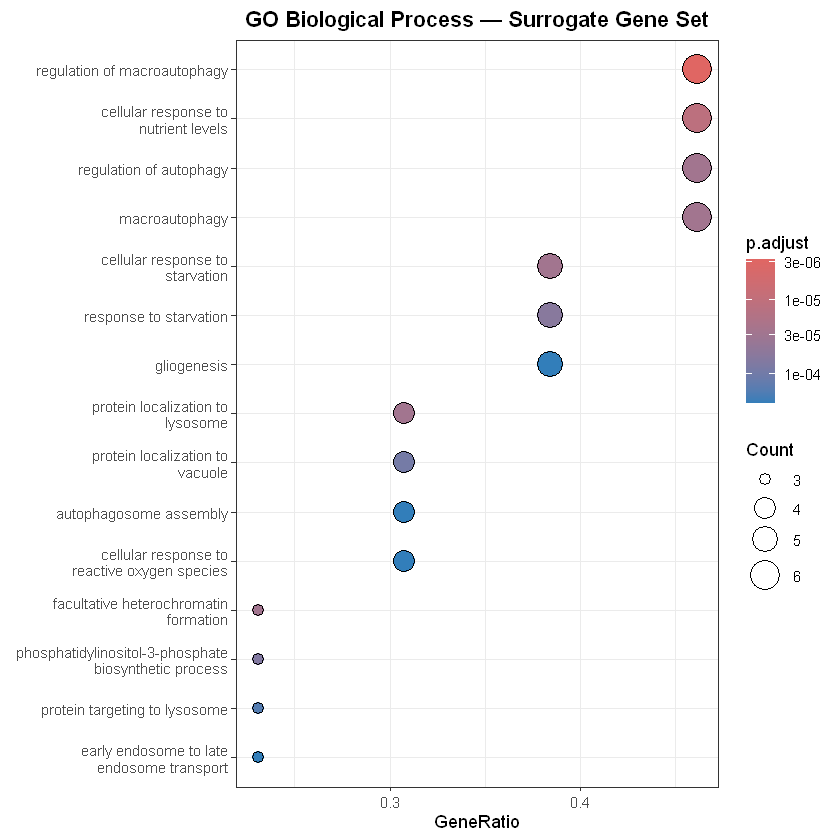

In [12]:
# Dotplot — Biological Process
dotplot(go_bp, showCategory = 15, title = "GO Biological Process — Surrogate Gene Set") +
  theme_bw() +
  theme(
    axis.text.y  = element_text(size = 9),
    plot.title   = element_text(face = "bold", hjust = 0.5)
  )


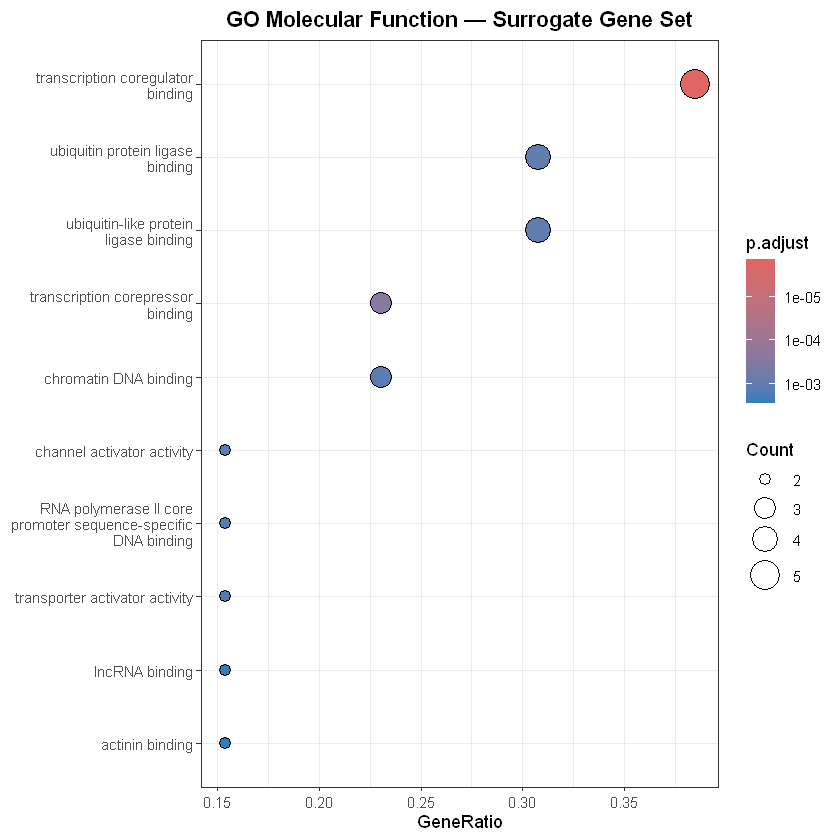

In [13]:
# Dotplot — Molecular Function
dotplot(go_mf, showCategory = 10, title = "GO Molecular Function — Surrogate Gene Set") +
  theme_bw() +
  theme(
    axis.text.y  = element_text(size = 9),
    plot.title   = element_text(face = "bold", hjust = 0.5)
  )


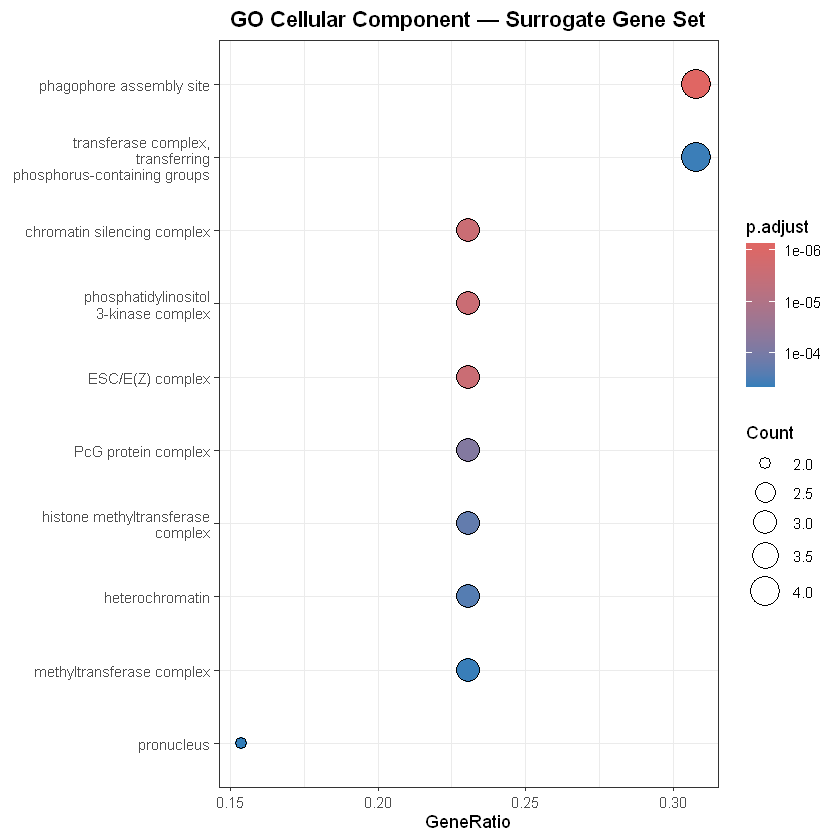

In [14]:
# Dotplot — Cellular Component
dotplot(go_cc, showCategory = 10, title = "GO Cellular Component — Surrogate Gene Set") +
  theme_bw() +
  theme(
    axis.text.y  = element_text(size = 9),
    plot.title   = element_text(face = "bold", hjust = 0.5)
  )


In [15]:
# Gene concept network — BP (shows which genes drive which terms)
if (nrow(as.data.frame(go_bp)) > 0) {
  cnetplot(go_bp, showCategory = 8, foldChange = NULL,
           colorEdge = TRUE, node_label = "all") +
    ggtitle("GO-BP Gene-Concept Network") +
    theme(plot.title = element_text(face = "bold", hjust = 0.5))
}


ERROR: Error in layout(data, ...): unused argument (colorEdge = TRUE)


In [ ]:
# Enrichment map — groups related GO terms
if (nrow(as.data.frame(go_bp)) >= 2) {
  go_bp_sim <- pairwise_termsim(go_bp)
  emapplot(go_bp_sim, showCategory = 15) +
    ggtitle("GO-BP Enrichment Map") +
    theme(plot.title = element_text(face = "bold", hjust = 0.5))
}


## 7. KEGG Pathway Enrichment

In [ ]:
kegg_res <- enrichKEGG(
  gene         = surrogate_entrez$ENTREZID,
  organism     = "hsa",
  pvalueCutoff = 0.05
)

# Make gene symbols readable
kegg_res <- setReadable(kegg_res, OrgDb = org.Hs.eg.db, keyType = "ENTREZID")

cat("KEGG pathways found:", nrow(as.data.frame(kegg_res)), "\n")
head(as.data.frame(kegg_res)[, c("Description", "pvalue", "p.adjust", "Count", "geneID")], 10)


In [ ]:
dotplot(kegg_res, showCategory = 15,
        title = "KEGG Pathway Enrichment — Surrogate Gene Set") +
  theme_bw() +
  theme(
    axis.text.y = element_text(size = 9),
    plot.title  = element_text(face = "bold", hjust = 0.5)
  )


## 8. Reactome Pathway Enrichment

In [ ]:
reactome_res <- enrichPathway(
  gene          = surrogate_entrez$ENTREZID,
  pvalueCutoff  = 0.05,
  readable      = TRUE
)

cat("Reactome pathways found:", nrow(as.data.frame(reactome_res)), "\n")
head(as.data.frame(reactome_res)[, c("Description", "pvalue", "p.adjust", "Count", "geneID")], 10)


In [ ]:
dotplot(reactome_res, showCategory = 15,
        title = "Reactome Pathway Enrichment — Surrogate Gene Set") +
  theme_bw() +
  theme(
    axis.text.y = element_text(size = 9),
    plot.title  = element_text(face = "bold", hjust = 0.5)
  )


## 9. Export All Results to CSV

In [ ]:
output_dir <- "./GO_Pathway_Results"
dir.create(output_dir, showWarnings = FALSE)

write.csv(as.data.frame(tmigd3_go_bp),  file.path(output_dir, "TMIGD3_GO_BP.csv"),        row.names = FALSE)
write.csv(as.data.frame(tmigd3_go_mf),  file.path(output_dir, "TMIGD3_GO_MF.csv"),        row.names = FALSE)
write.csv(as.data.frame(tmigd3_go_cc),  file.path(output_dir, "TMIGD3_GO_CC.csv"),        row.names = FALSE)
write.csv(as.data.frame(tmigd3_reactome), file.path(output_dir, "TMIGD3_Reactome.csv"),   row.names = FALSE)

write.csv(as.data.frame(go_bp),         file.path(output_dir, "Surrogate_GO_BP.csv"),     row.names = FALSE)
write.csv(as.data.frame(go_mf),         file.path(output_dir, "Surrogate_GO_MF.csv"),     row.names = FALSE)
write.csv(as.data.frame(go_cc),         file.path(output_dir, "Surrogate_GO_CC.csv"),     row.names = FALSE)
write.csv(as.data.frame(kegg_res),      file.path(output_dir, "Surrogate_KEGG.csv"),      row.names = FALSE)
write.csv(as.data.frame(reactome_res),  file.path(output_dir, "Surrogate_Reactome.csv"),  row.names = FALSE)

cat("All results saved to:", output_dir, "\n")
list.files(output_dir)


## 10. Interpretation Guide

### Expected Biological Themes
Based on the known biology of the surrogate genes, you should expect enrichment in:

| Pathway / Process | Source Gene(s) | Relevance to Radioresistance |
|---|---|---|
| Chromatin organization / PRC2 complex | LUADT1 → SUZ12, EZH2, EED | Epigenetic silencing of tumour suppressors |
| Cell cycle regulation / G1-S checkpoint | LUADT1 → CDKN1B (p27) | Cell cycle arrest evasion |
| Autophagy / PI3K complex | LOC100128906 → WDR45, BECN1 | Survival under cellular stress / radiation |
| NF-κB signalling | TMIGD3 → RELA, NFKB1 | Pro-survival / anti-apoptotic signalling |
| PI3K-Akt signalling | TMIGD3 → AKT1 | Radiation survival pathway |

### Connecting Back to Your Paper
These pathways link mechanistically to the integrin αvβ3 / thyroid hormone radioresistance
axis described in Glinsky et al. 2024 — particularly the NF-κB and Akt survival pathways,
and epigenetic regulation via PRC2, which are known downstream effectors of integrin signalling.

### Next Steps
1. Add LINC02728 co-expressed partners from your expression matrix (Section 4)
2. Validate top GO/pathway hits against your original DEG list
3. STRING network analysis: import surrogate gene set into Cytoscape + stringApp
4. Cross-reference enriched pathways with your radiation treatment condition
